**Problem 1**

**Problem Setup**   
• Dataset: MNISTorFashion-MNIST ( you can import dataset from torchvision.datasets.MNIST)   
• Input shape: 28×28    
• 28×28 grayscale images, flattened to 784  
• Batch size: fixed (e.g., 64)


**Task**    
• Train a multi-layer perceptron (MLP) for classification.  
• During training, record and visualize the evolution of hidden-layer activation distributions.     


**Network Architecture**    
Use a simple, deliberately unstable model, below is an example Sequential Pytorch Model:    
Input → Linear(784 → 256) → ReLU    
Linear(256 → 128) → ReLU    
Linear(128 → 64) → ReLU     
Linear(64 → 10)

    

In [8]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )


In [10]:
image, label = train_data[0] 

print(image.shape)
print(label)

image = image.view(-1)
print(image.shape)


torch.Size([1, 28, 28])
5
torch.Size([784])


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)


In [19]:
# Fix one batch for monitoring
fixed_images, fixed_labels = next(iter(train_loader))

In [20]:
from torch import nn
from torch import relu
from torch.optim import Adam

class MLP(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.input_layer = nn.Linear(28*28, 256)
        self.hidden_layer1 = nn.Linear(256, 128)
        self.hidden_layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0),-1)
        x = relu(self.input_layer(x))
        x = relu(self.hidden_layer1(x))
        x = relu(self.hidden_layer2(x))
        x = relu(self.output_layer(x))
        return x
    
model = MLP()

In [21]:
# -----------------------------
# 3. Hooks to record activations
# -----------------------------
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

model.input_layer.register_forward_hook(get_activation('input_layer'))
model.hidden_layer1.register_forward_hook(get_activation('hidden_layer1'))
model.hidden_layer1.register_forward_hook(get_activation('hidden_layer2'))

In [39]:
import torch
import matplotlib.pyplot as plt

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.01)

history = { 'input_layer': [], 'hidden_layer1': [], 'hidden_layer2': [] }
stats = { 'input_layer': {'mean': [], 'var': []},
          'hidden_layer1': {'mean': [], 'var': []},
          'hidden_layer2': {'mean': [], 'var': []} }
num_epochs = 5

# Training loop
for epoch in range(num_epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model.forward(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {(loss.item()):.2f}")

    # Forward pass on fixed batch to record activations
    with torch.no_grad():
        _ = model(fixed_images)

    # Save histograms and compute mean/variance
    for layer_name, act in activations.items():
        flat = act.view(-1).cpu().numpy()

        # Histogram
        history[layer_name].append(flat)

        # Mean and variance
        mean_val = act.mean().item()
        var_val = act.var().item()
        stats[layer_name]['mean'].append(act.mean().item())
        stats[layer_name]['var'].append(act.var().item())
        print(f"Epoch {epoch+1}, {layer_name}: mean={mean_val:.4f}, var={var_val:.4f}")        

    # print(history)    

Epoch 1, Loss: 1.79
Epoch 1, input_layer: mean=-38.2245, var=1361.6190
Epoch 1, hidden_layer1: mean=-10.5061, var=685.0635
Epoch 1, hidden_layer2: mean=-10.5061, var=685.0635
Epoch 2, Loss: 1.85
Epoch 2, input_layer: mean=-39.6628, var=1635.3252
Epoch 2, hidden_layer1: mean=-6.4227, var=297.3004
Epoch 2, hidden_layer2: mean=-6.4227, var=297.3004
Epoch 3, Loss: 2.08
Epoch 3, input_layer: mean=-39.6137, var=1639.0513
Epoch 3, hidden_layer1: mean=-6.9305, var=335.1756
Epoch 3, hidden_layer2: mean=-6.9305, var=335.1756
Epoch 4, Loss: 1.86
Epoch 4, input_layer: mean=-40.0100, var=1792.4249
Epoch 4, hidden_layer1: mean=-7.1553, var=331.1601
Epoch 4, hidden_layer2: mean=-7.1553, var=331.1601
Epoch 5, Loss: 2.19
Epoch 5, input_layer: mean=-40.0320, var=1814.8398
Epoch 5, hidden_layer1: mean=-7.5313, var=365.1263
Epoch 5, hidden_layer2: mean=-7.5313, var=365.1263


MovieWriter ffmpeg unavailable; using Pillow instead.


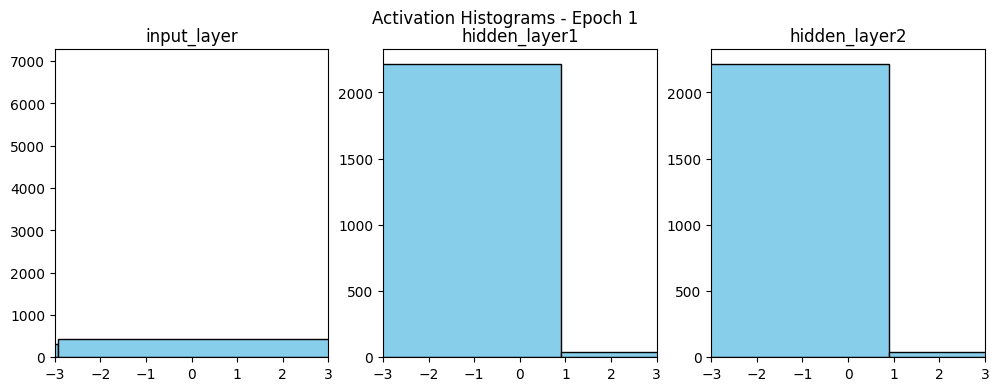

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# -----------------------------
# 6. Animation of histograms
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
layer_names = ['input_layer', 'hidden_layer1', 'hidden_layer2']

def update(epoch):
    fig.suptitle(f"Activation Histograms - Epoch {epoch+1}")
    for ax, layer in zip(axes, layer_names):
        ax.clear()
        ax.hist(history[layer][epoch], bins=50, color='skyblue', edgecolor='black')
        ax.set_title(layer)
        ax.set_xlim([-3, 3])  # adjust for visibility
    return axes

ani = animation.FuncAnimation(fig, update, frames=num_epochs, repeat=False)
ani.save(filename='anim.gif')
HTML(ani.to_jshtml())
# plt.show()

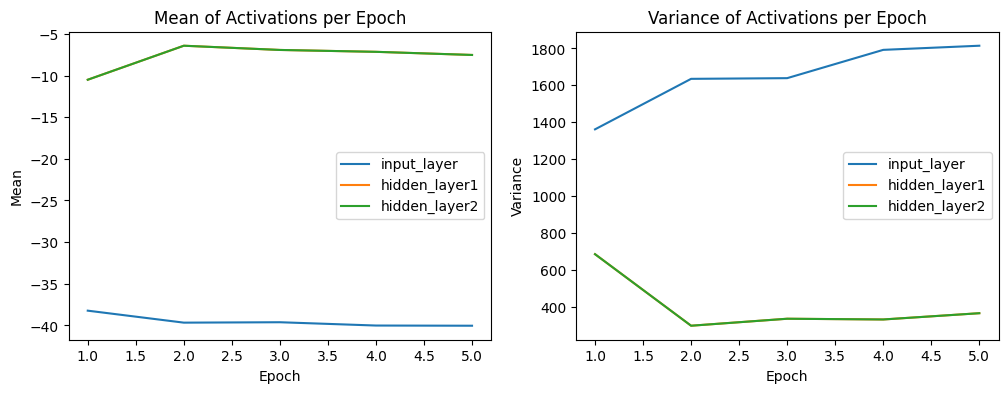

In [40]:
# -----------------------------
# 6. Plot mean and variance curves
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Mean plot
for layer_name in stats:
    axes[0].plot(range(1, num_epochs+1), stats[layer_name]['mean'], label=layer_name)
axes[0].set_title("Mean of Activations per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean")
axes[0].legend()

# Variance plot
for layer_name in stats:
    axes[1].plot(range(1, num_epochs+1), stats[layer_name]['var'], label=layer_name)
axes[1].set_title("Variance of Activations per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Variance")
axes[1].legend()

plt.show()

**Problem 4**
Problem Statement: Consider the following non-convex function (Rosenbrock function):        
> f(x,y) = x^2 +100(y −x^2)^2     

Tasks       
1. Implement the following optimization algorithms from scratch (do not use built-in optimizers from PyTorch/TensorFlow):       
• Vanilla Gradient Descent (SGD)        
• Adam optimizer        


In [62]:
import numpy as np

def rosenbrock(x, y) -> np.longdouble:
    return (x**2 + 100 * (y - x**2)**2)

def rosenbrock_derivative(x, y) -> np.longdouble:
    return np.array([2*x - 400 *(y - x**2)*x, 200 * (y - x**2)])

def sgd(epochs=1000, lr=0.01, start=[0.0, 0.0]):
    x,y = start
    x = np.clip(x, -10, 10)
    y = np.clip(y, -10, 10)    

    history = [(x,y, rosenbrock(x,y))]
    print(f"Epoch {0}: x={x:.4f}, y={y:.4f}, f(x,y)={rosenbrock(x,y):.6f}")

    for epoch in range(1, epochs):
        df = rosenbrock_derivative(x,y)
        x -= lr * df[0]
        y -= lr * df[1]
        history.append((x,y, rosenbrock(x,y)))
        if epoch % 500 == 0:
            print(f"Epoch {epoch}: x={x:.4f}, y={y:.4f}, f(x,y)={rosenbrock(x,y):.6f}")

    return history    

In [65]:
def adam(lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, epochs=5000, start=(-1.2, 1.0)):
    x, y = start
    m = np.zeros(2)  # first moment
    v = np.zeros(2)  # second moment
    history = [(x, y, rosenbrock(x,y))]
    print(f"[Adam] Epoch {0}: x={x:.4f}, y={y:.4f}, f={rosenbrock(x,y):.6f}")
    
    for epoch in range(1, epochs):
        g = rosenbrock_derivative(x, y)
        
        # Update biased first moment estimate
        m = beta1 * m + (1 - beta1) * g
        # Update biased second raw moment estimate
        v = beta2 * v + (1 - beta2) * (g**2)
        
        # Bias correction
        m_hat = m / (1 - beta1**epoch)
        v_hat = v / (1 - beta2**epoch)
        
        # Parameter update
        x -= lr * m_hat[0] / (np.sqrt(v_hat[0]) + eps)
        y -= lr * m_hat[1] / (np.sqrt(v_hat[1]) + eps)
        
        history.append((x, y, rosenbrock(x,y)))
        if epoch % 500 == 0:
            print(f"[Adam] Epoch {epoch}: x={x:.4f}, y={y:.4f}, f={rosenbrock(x,y):.6f}")
    return history

2. Use the same learning rate 10−3 initialization for both methods.     
3. Optimize the function starting from the initial point: (x0, y0) = (−1.5,1.5)     
4. Run both optimizers for 5000 iterations      

In [63]:
# Setting Configuration as per instruction
lr = 0.001
epochs = 5000
start = (-1.5, 1.5)

# Run optimization
history = sgd(lr=lr, epochs=epochs, start=start)

Epoch 0: x=-1.5000, y=1.5000, f(x,y)=58.500000
Epoch 500: x=-1.0624, y=1.1327, f(x,y)=1.130280
Epoch 1000: x=-0.8578, y=0.7396, f(x,y)=0.737258
Epoch 1500: x=-0.6270, y=0.3962, f(x,y)=0.394118
Epoch 2000: x=-0.3801, y=0.1463, f(x,y)=0.144846
Epoch 2500: x=-0.1759, y=0.0315, f(x,y)=0.030957
Epoch 3000: x=-0.0682, y=0.0047, f(x,y)=0.004650
Epoch 3500: x=-0.0253, y=0.0007, f(x,y)=0.000638
Epoch 4000: x=-0.0093, y=0.0001, f(x,y)=0.000086
Epoch 4500: x=-0.0034, y=0.0000, f(x,y)=0.000012


In [66]:
adam_history = adam(lr=lr, epochs=epochs, start=start)

[Adam] Epoch 0: x=-1.5000, y=1.5000, f=58.500000
[Adam] Epoch 500: x=-1.3044, y=1.6990, f=1.702279
[Adam] Epoch 1000: x=-1.2995, y=1.6922, f=1.689948
[Adam] Epoch 1500: x=-1.2946, y=1.6794, f=1.677152
[Adam] Epoch 2000: x=-1.2878, y=1.6618, f=1.659517
[Adam] Epoch 2500: x=-1.2786, y=1.6383, f=1.636048
[Adam] Epoch 3000: x=-1.2666, y=1.6077, f=1.605395
[Adam] Epoch 3500: x=-1.2509, y=1.5681, f=1.565815
[Adam] Epoch 4000: x=-1.2304, y=1.5174, f=1.515132
[Adam] Epoch 4500: x=-1.2040, y=1.4529, f=1.450701


 Plot the following:        
• Function value vs. iterations     
• Optimization trajectory on a 2D contour plot of the Rosenbrock function       

In [6]:
len(history)
print(history)

[(np.float64(-1.5), np.float64(1.5), np.longdouble('58.5')), (np.float64(-1.947), np.float64(1.65), np.longdouble('58.5')), (np.float64(-2.394), np.float64(1.7999999999999998), np.longdouble('58.5')), (np.float64(-2.841), np.float64(1.9499999999999997), np.longdouble('58.5')), (np.float64(-3.2880000000000003), np.float64(2.0999999999999996), np.longdouble('58.5')), (np.float64(-3.7350000000000003), np.float64(2.2499999999999996), np.longdouble('58.5')), (np.float64(-4.182), np.float64(2.3999999999999995), np.longdouble('58.5')), (np.float64(-4.6290000000000004), np.float64(2.5499999999999994), np.longdouble('58.5')), (np.float64(-5.0760000000000005), np.float64(2.6999999999999993), np.longdouble('58.5')), (np.float64(-5.523000000000001), np.float64(2.849999999999999), np.longdouble('58.5')), (np.float64(-5.970000000000001), np.float64(2.999999999999999), np.longdouble('58.5')), (np.float64(-6.417000000000001), np.float64(3.149999999999999), np.longdouble('58.5')), (np.float64(-6.864000

In [7]:
len(adam_history)

5000

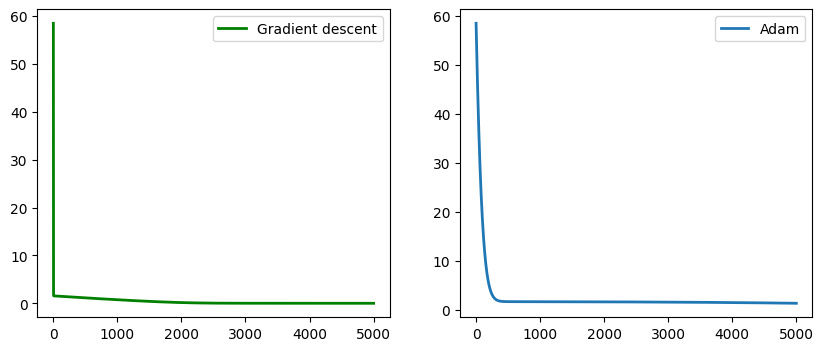

In [67]:
import matplotlib.pyplot as plt

history_array = np.array(history)
adam_history_array = np.array(adam_history)
fig, axess = plt.subplots(1,2, figsize=(10,4))

axess[0].plot(range(1, epochs+1), history_array[:, 2], linewidth=2, color='green', label='Gradient descent')
axess[0].legend()

axess[1].plot(range(1, epochs+1), adam_history_array[:, 2], linewidth=2, label='Adam')
axess[1].legend()

plt.show()

(400, 400)


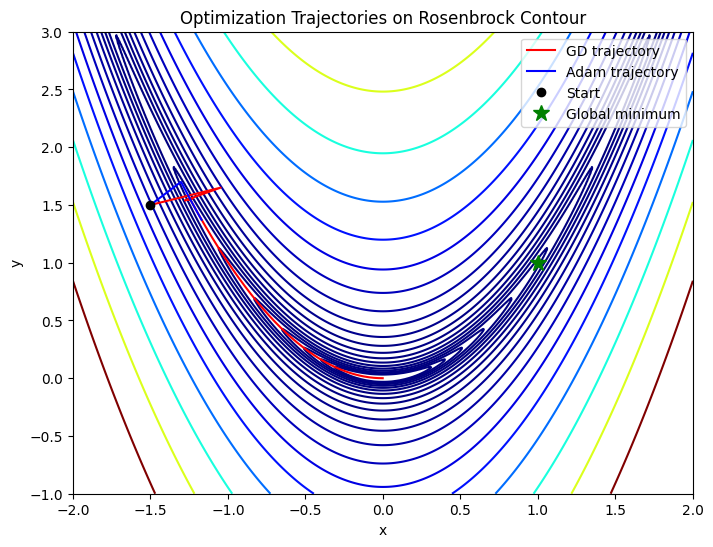

In [69]:
# -----------------------------
# Plot 2: Trajectory on Rosenbrock contour
# -----------------------------
X = np.linspace(-2, 2, 400)
Y = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(X, Y)
Z = rosenbrock(X, Y)
print(Z.shape)

plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap="jet")

plt.plot(history_array[:,0], history_array[:,1], 'r-', label="GD trajectory")
plt.plot(adam_history_array[:,0], adam_history_array[:,1], 'b-', label="Adam trajectory")

plt.plot(-1.5, 1.5, 'ko', label="Start")
plt.plot(1, 1, 'g*', markersize=12, label="Global minimum")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Optimization Trajectories on Rosenbrock Contour")
plt.legend()
plt.show()

Compare the two methods in terms of:    
• Convergence speed     
• Stability of updates      
• Sensitivity to learning rate      
η ∈{10^−1, 10^−2, 10^−3, 10^−4}      

In [77]:
lrs = [ 0.1, 0.001, 0.0001]
print("Experiment Run for SGD:")
for lr in lrs:
    print(f"Learning Rate: {lr}")
    x =sgd(lr=lr, epochs=epochs, start=start)

Experiment Run for SGD:
Learning Rate: 0.1
Epoch 0: x=-1.5000, y=1.5000, f(x,y)=58.500000
Epoch 500: x=nan, y=nan, f(x,y)=nan
Epoch 1000: x=nan, y=nan, f(x,y)=nan
Epoch 1500: x=nan, y=nan, f(x,y)=nan
Epoch 2000: x=nan, y=nan, f(x,y)=nan
Epoch 2500: x=nan, y=nan, f(x,y)=nan
Epoch 3000: x=nan, y=nan, f(x,y)=nan
Epoch 3500: x=nan, y=nan, f(x,y)=nan
Epoch 4000: x=nan, y=nan, f(x,y)=nan
Epoch 4500: x=nan, y=nan, f(x,y)=nan
Learning Rate: 0.001
Epoch 0: x=-1.5000, y=1.5000, f(x,y)=58.500000
Epoch 500: x=-1.0624, y=1.1327, f(x,y)=1.130280
Epoch 1000: x=-0.8578, y=0.7396, f(x,y)=0.737258
Epoch 1500: x=-0.6270, y=0.3962, f(x,y)=0.394118
Epoch 2000: x=-0.3801, y=0.1463, f(x,y)=0.144846
Epoch 2500: x=-0.1759, y=0.0315, f(x,y)=0.030957
Epoch 3000: x=-0.0682, y=0.0047, f(x,y)=0.004650
Epoch 3500: x=-0.0253, y=0.0007, f(x,y)=0.000638
Epoch 4000: x=-0.0093, y=0.0001, f(x,y)=0.000086
Epoch 4500: x=-0.0034, y=0.0000, f(x,y)=0.000012
Learning Rate: 0.0001
Epoch 0: x=-1.5000, y=1.5000, f(x,y)=58.500000
E

C:\Users\ankit\AppData\Local\Temp\ipykernel_2392\4075994284.py:4: RuntimeWarning: overflow encountered in scalar power
  return (x**2 + 100 * (y - x**2)**2)
C:\Users\ankit\AppData\Local\Temp\ipykernel_2392\4075994284.py:7: RuntimeWarning: overflow encountered in scalar power
  return np.array([2*x - 400 *(y - x**2)*x, 200 * (y - x**2)])
C:\Users\ankit\AppData\Local\Temp\ipykernel_2392\4075994284.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return (x**2 + 100 * (y - x**2)**2)
C:\Users\ankit\AppData\Local\Temp\ipykernel_2392\4075994284.py:7: RuntimeWarning: invalid value encountered in scalar subtract
  return np.array([2*x - 400 *(y - x**2)*x, 200 * (y - x**2)])


In [ ]:
lrs = [0.1, 0.01, 0.001, 0.0001]
print("Experiment Run for Adam:")
for lr in lrs:
    print(f"Learning Rate: {lr}")
    x =adam(lr=lr, epochs=epochs, start=start)


Learning Rate: 0.1
[Adam] Epoch 0: x=-1.5000, y=1.5000, f=58.500000
[Adam] Epoch 500: x=-0.4058, y=0.1657, f=0.164797
[Adam] Epoch 1000: x=-0.0033, y=0.0000, f=0.000011
[Adam] Epoch 1500: x=-0.0000, y=0.0000, f=0.000000
[Adam] Epoch 2000: x=-0.0000, y=0.0000, f=0.000000
[Adam] Epoch 2500: x=-0.0000, y=0.0000, f=0.000000
[Adam] Epoch 3000: x=-0.0000, y=0.0000, f=0.000000
[Adam] Epoch 3500: x=0.0000, y=-0.0000, f=0.000000
[Adam] Epoch 4000: x=-0.0000, y=-0.0000, f=0.000000
[Adam] Epoch 4500: x=0.0000, y=0.0000, f=0.000000
Learning Rate: 0.01
[Adam] Epoch 0: x=-1.5000, y=1.5000, f=58.500000
[Adam] Epoch 500: x=-1.2486, y=1.5623, f=1.560044
[Adam] Epoch 1000: x=-1.1358, y=1.2931, f=1.290957
[Adam] Epoch 1500: x=-0.9615, y=0.9272, f=0.925206
[Adam] Epoch 2000: x=-0.7161, y=0.5149, f=0.513226
[Adam] Epoch 2500: x=-0.4168, y=0.1747, f=0.173785
[Adam] Epoch 3000: x=-0.1652, y=0.0275, f=0.027287
[Adam] Epoch 3500: x=-0.0437, y=0.0019, f=0.001906
[Adam] Epoch 4000: x=-0.0075, y=0.0001, f=0.00005


|Aspect|	Gradient Descent (SGD)|	Adam Optimizer|
|-|-|-|
|Convergence Speed|	Slow, steady|	Fast, efficient|
|Stability|	Oscillates, fragile|	Stable, smooth|
|Learning Rate Sens.|	Very high- leads to scalar overflow for 10^-1, 10^-2. Better stability for 10^-3, 10^-4|	Moderate: Better stability at 10^-3 10^-4, but not unstable numerically at 10^-1, 10^-2|

**Problem 6**

Programming + Analysis: RMSProp vs Adam     
Consider the non-convex function:       
f(w1,w2) = 1/2 *(w1^2 + 1000w2^2) + 5*sin(w1)

(a) Implement RMSProp and Adam from scratch.        
(b) Initialize at (w1,w2)=(2,2)     
    Run for 200 iterations.        
(c)Report:      
•Finalparametervalues       
•Final loss     
•Plot lossvs iterations(logscale)       

f(w1,w2) = 1/2 *(w1^2 + 1000w2^2) + 5*sin(w1)

In [11]:
import numpy as np

def func(w1,w2):
    return 0.5 * (w1**2 + 100*w2**2) + 5 * np.sin(w1)

def grad(w1, w2):
    return np.array([w1 + 5 *np.cos(w1), 100*w2])

(a) Implement RMSProp and Adam from scratch

In [34]:
def adam(lr=0.001, beta1=0.9, beta2=0.99, eps=1e-8, epochs=1000, start=(-1.2, 1.0)):
    w1, w2 = start
    
    # First Moment; Needs to be of same vector size as input; here 2
    # First Moment: Tracks exponential decaying of average gradients
    m = np.zeros(2)
    # Second Moment; Needs to be of same vector size as input; here 2
    # Second Moment: Tracks exponential decaying average of squared gradients
    v = np.zeros(2)
    losses = []

    adam_history = [(w1,w2, func(w1,w2))]

    print(f"[Adam] Epoch {0}: w1={w1:.4f}, w2={w2:.4f}, f={func(w1,w2):.6f}")
    for epoch in range(1, epochs+1):
        g = grad(w1, w2)

        # Moments bias update
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2

        # Bias correction
        m_hat = m / (1-beta1**epoch)
        v_hat = v / (1-beta2**epoch)

        # Parameter update
        w1 -= lr * m_hat[0] / (np.sqrt(v_hat[0] + eps))
        w2 -= lr * m_hat[1] / (np.sqrt(v_hat[1] + eps))

        adam_history.append((w1,w2, func(w1,w2)))
        if epoch % 20 == 0:
            print(f"[Adam] Epoch {epoch}: w1={w1:.4f}, w2={w2:.4f}, f={func(w1,w2):.6f}")

    return adam_history

(b) Initialize at (w1,w2)=(2,2)     
    Run for 200 iterations      

In [39]:
adam_hist = adam(lr=0.001, epochs=200, start=(2,2))
adam_hist = np.array(adam_hist)

[Adam] Epoch 0: w1=2.0000, w2=2.0000, f=206.546487
[Adam] Epoch 20: w1=2.0206, w2=1.9800, f=202.566223
[Adam] Epoch 40: w1=2.0433, w2=1.9601, f=198.634360
[Adam] Epoch 60: w1=2.0682, w2=1.9402, f=194.754693
[Adam] Epoch 80: w1=2.0943, w2=1.9204, f=190.927160
[Adam] Epoch 100: w1=2.1211, w2=1.9007, f=187.150581
[Adam] Epoch 120: w1=2.1482, w2=1.8811, f=183.423652
[Adam] Epoch 140: w1=2.1753, w2=1.8615, f=179.745148
[Adam] Epoch 160: w1=2.2022, w2=1.8420, f=176.113945
[Adam] Epoch 180: w1=2.2289, w2=1.8226, f=172.529007
[Adam] Epoch 200: w1=2.2553, w2=1.8032, f=168.989378


(a) Implement RMSProp and Adam from scratch

In [36]:
def rmsprop(lr=0.01, beta=0.9, eps=1e-8, epochs=1000, start=(-1.2, 1.0)):
    w1, w2 = start

    s = np.zeros(2)
    rms_history = [(w1,w2,func(w1,w2))]
    print(f"[RMSProp] Epoch {0}: w1={w1:.4f}, w2={w2:.4f}, f={func(w1,w2):.6f}")

    for epoch in range(1, epochs+1):
        g = grad(w1, w2)
        s = beta * s + (1-beta) * g**2

        w1 -= lr * g[0] / (np.sqrt(s[0]) + eps)
        w2 -= lr * g[1] / (np.sqrt(s[1]) + eps)

        rms_history.append((w1,w2,func(w1,w2)))
        if epoch % 20 == 0:
            print(f"[RMSProp] Epoch {epoch}: w1={w1:.4f}, w2={w2:.4f}, f={func(w1,w2):.6f}")

    return rms_history

(b) Initialize at (w1,w2)=(2,2)     
    Run for 200 iterations      

In [40]:
rms_hist = rmsprop(lr=0.001, epochs=200, start=(2,2))
rms_hist = np.array(rms_hist)

[RMSProp] Epoch 0: w1=2.0000, w2=2.0000, f=206.546487
[RMSProp] Epoch 20: w1=2.0322, w2=1.9715, f=200.881346
[RMSProp] Epoch 40: w1=2.0559, w2=1.9511, f=196.870790
[RMSProp] Epoch 60: w1=2.0782, w2=1.9311, f=192.987820
[RMSProp] Epoch 80: w1=2.1000, w2=1.9112, f=189.153536
[RMSProp] Epoch 100: w1=2.1215, w2=1.8913, f=185.358905
[RMSProp] Epoch 120: w1=2.1427, w2=1.8714, f=181.602867
[RMSProp] Epoch 140: w1=2.1637, w2=1.8515, f=177.885319
[RMSProp] Epoch 160: w1=2.1846, w2=1.8316, f=174.206277
[RMSProp] Epoch 180: w1=2.2054, w2=1.8117, f=170.565766
[RMSProp] Epoch 200: w1=2.2262, w2=1.7918, f=166.963814


(c)Report:  
•Final parameter values     
•Final loss     
•Plot loss vs iterations(log scale)      

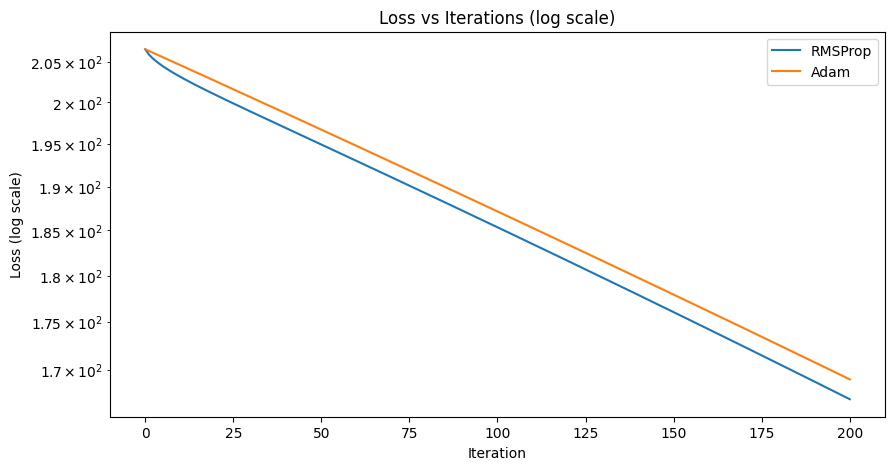

RMSProp final params: 2.2261772319222857 1.7917689736434836
RMSProp final loss: 166.9638144730204
Adam final params: 2.2552896017577764 1.803177831773272
Adam final loss: 168.98937793837416


In [41]:
import matplotlib.pyplot as plt

# Extract losses
rms_losses = rms_hist[:, 2]
adam_losses = adam_hist[:,2]

# Plot
plt.figure(figsize=(10,5))
plt.plot(rms_losses, label="RMSProp")
plt.plot(adam_losses, label="Adam")
plt.yscale("log")  # log scale for loss
plt.xlabel("Iteration")
plt.ylabel("Loss (log scale)")
plt.title("Loss vs Iterations (log scale)")
plt.legend()
plt.show()

# Print final results
print("RMSProp final params:", rms_hist[-1,0], rms_hist[-1,1])
print("RMSProp final loss:", rms_hist[-1,2])
print("Adam final params:", adam_hist[-1,0], adam_hist[-1,1])
print("Adam final loss:", adam_hist[-1,2])

**Problem 8**       

Empirically validate the need for specific weight initialization strategies.        

*Task*: Build a 2-layer Multilayer Perceptron (MLP) without using high-level framework layers (e.g., use NumPy matrix multiplications).     
Pass a batch of normally distributed inputs through the network. Record and plot the variance of the activations (plot the histogram    
of each neurons activation value) at each layer using four different initialization schemes:        
Zero initialization , standard random normal initialization, Xavier initialization for Sigmoid activations (N(0, 2nin+nout)), and 
Kaiming He initialization for ReLU activations (N(0, 2nin))


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration
batch_size = 128
input_dim = 3
hidden_dims = [5, 5]
output_dim = 5

# Input: Normally distributed batch
X = np.random.randn(batch_size, input_dim)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def run_simulation(init_type):
    # Layer dims: [3, 5, 5, 5]
    dims = [input_dim] + hidden_dims + [output_dim]
    activations = []
    curr_input = X
    
    for i in range(len(dims) - 1):
        n_in, n_out = dims[i], dims[i+1]
        
        # Initialization Schemes
        if init_type == 'zero':
            W = np.zeros((n_in, n_out))
        elif init_type == 'standard':
            W = np.random.randn(n_in, n_out)
        elif init_type == 'xavier':
            W = np.random.randn(n_in, n_out) * np.sqrt(2 / (n_in + n_out))
        elif init_type == 'he':
            W = np.random.randn(n_in, n_out) * np.sqrt(2 / n_in)
            
        # Forward Pass
        z = np.dot(curr_input, W)
        
        # Apply Activation (except for the last output layer)
        if i < len(dims) - 2:
            a = sigmoid(z) if init_type == 'xavier' else relu(z)
        else:
            a = z # Output layer (linear)
            
        activations.append(a)
        curr_input = a
        
    return activations


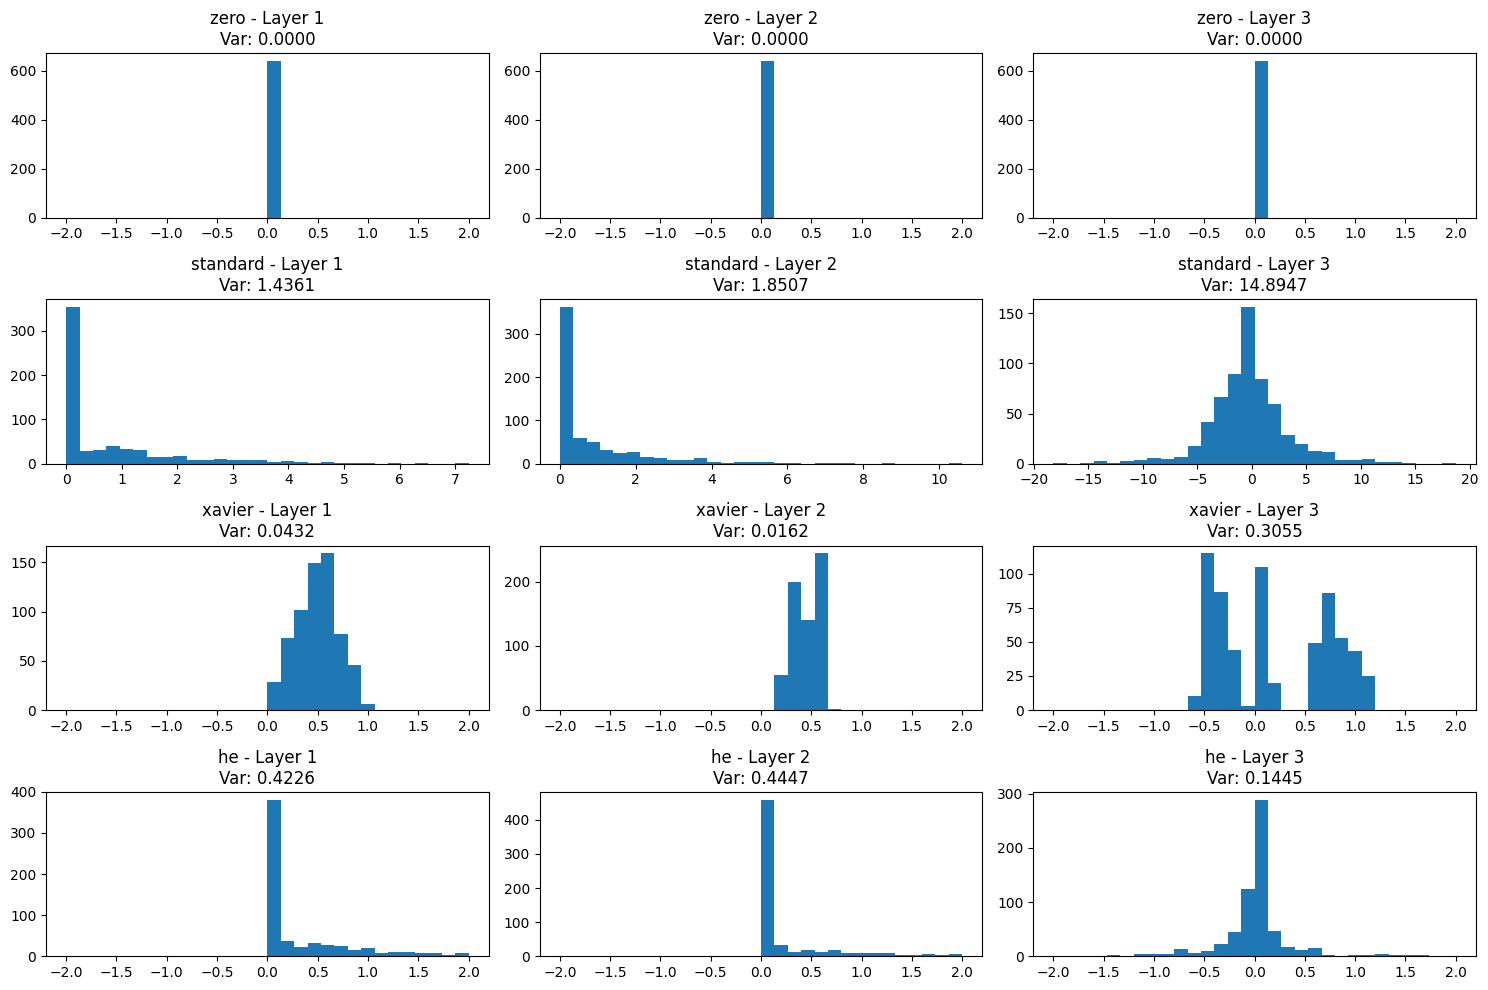

In [43]:
# Run and Plot
schemes = ['zero', 'standard', 'xavier', 'he']
fig, axes = plt.subplots(len(schemes), 3, figsize=(15, 10))

for idx, scheme in enumerate(schemes):
    acts = run_simulation(scheme)
    for layer_idx, a in enumerate(acts):
        axes[idx, layer_idx].hist(a.flatten(), bins=30, range=(-2, 2) if scheme != 'standard' else None)
        axes[idx, layer_idx].set_title(f"{scheme} - Layer {layer_idx+1}\nVar: {np.var(a):.4f}")

plt.tight_layout()
plt.show()

**Problem 10**

Consider a single neuron model with ReLU activation:    
z =wx   
a =ReLU(z) = max(0,z)   
Loss function:  
RMSProp update:     
Where:      
• x : input     
• y : target output     
• w : weight parameter      
• gt = ∂L/∂w: gradient      
• β : decay rate        
• η : learning rate     
• ϵ : numerical stability term      
L = 1/2 (a−y)^2

vt = βvt−1 +(1−β)gt^2       
wt+1 = wt − (η /√vt +ϵ) *gt     


Task: Code RMSProp from scratch     
Take initialize: w = 1.5    
Input: x = 2    
Target: y = 1   
η =0.01, β = 0.9    
Run for 20 iterations and Plot loss vs iteration    

In [50]:
import numpy as np

def func(w, x):
    return w*x

def grad(w,x):
    return w

def relu(x):
    return np.maximum(0, x)

def loss(a, y):
    return 0.5* (a - y)**2

def rmsprop(x=2, y=1, lr=0.01, beta=0.9, eps=1e-8, epochs=20, start=1.5):
    w = start
    s = np.zeros(1)

    losses = []
    for epoch in range(1, epochs+1):
        g = grad(w, x)

        s = beta * s + (1-beta) * g**2

        w -= lr * g / (np.sqrt(s) + eps)
        z = func(w,x)
        a = relu(z)
        losses.append(loss(a, y))

    return losses

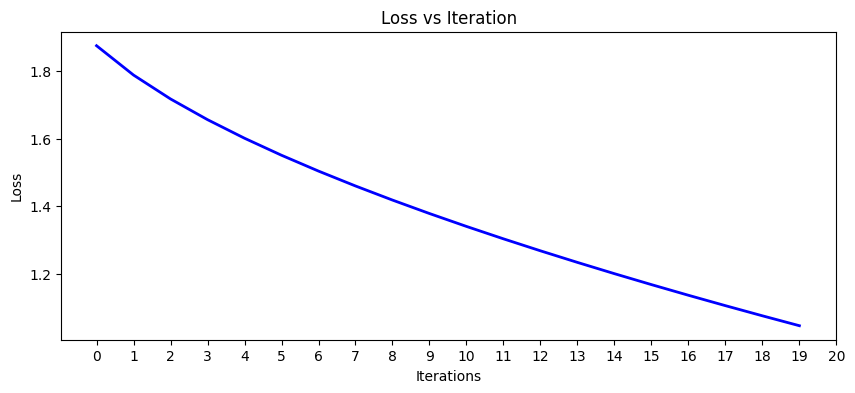

In [58]:
import matplotlib.pyplot as plt

losses = rmsprop(2,1)
plt.figure(figsize=(10,4))

plt.plot(range(0, len(losses)), losses, linewidth=2, color='blue', label="Loss")
plt.xticks(range(0, 20+1))
plt.title("Loss vs Iteration")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()

**Problem 12**      

Optimization in a Non-Convex Loss   
Consider the non-convex function: L(x) = x^4 −4*x^2 +x     
1. Plot L(x) for x ∈ [−3,3] and identify the number of local minima.    
2. Implement Gradient Descent and Adam from scratch.    
3. Run both optimizers for 300 iterations from: x0 = −1.5 and x0 =+1.5.     
4. Plot the loss curve and overlay the optimization trajectories.       
5. Report the final converged values. Briefly explain:      
• Why different initializations converge to different minima.       
• Why fixing random seeds is important for reproducibility.     
• Whytrying multiple seeds can help discover better minima in non-convex problems   

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def L(x):
    return x**4 - 4 * x**2 + x

def dL(x):
    return 4*x**3 - 8 * x + 1

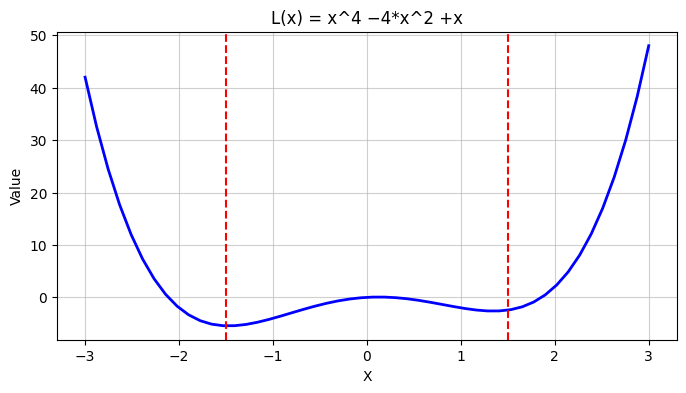

In [7]:
X = np.linspace(-3, 3, 50)
Y = L(X)

plt.figure(figsize=(8,4))

plt.plot(X, Y, linewidth=2, color='blue')
plt.title("L(x) = x^4 −4*x^2 +x")
plt.axvline(x=1.5, linestyle="--", color='red')
plt.axvline(x=-1.5, linestyle="--", color='red')
plt.xlabel("X")
plt.ylabel("Value")
plt.grid(True, alpha=0.6)
plt.show()


 Implement Gradient Descent and Adam from scratch

In [13]:
def adam(lr=0.001, beta1=0.9, beta2=0.99, eps=1e-8, epochs=1000, start=1.0):
    x = start
    
    # First Moment; Needs to be of same vector size as input; here 2
    # First Moment: Tracks exponential decaying of average gradients
    m = np.zeros(1)
    # Second Moment; Needs to be of same vector size as input; here 2
    # Second Moment: Tracks exponential decaying average of squared gradients
    v = np.zeros(1)
    losses = []

    adam_history = [(x, L(x))]

    print(f"[Adam] Epoch {0}: x={x:.4f} f={L(x):.6f}")
    for epoch in range(1, epochs+1):
        g = dL(x)

        # Moments bias update
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2

        # Bias correction
        m_hat = m / (1-beta1**epoch)
        v_hat = v / (1-beta2**epoch)

        # Parameter update
        x -= lr * m_hat[0] / (np.sqrt(v_hat[0] + eps))

        adam_history.append((x, L(x)))
        if epoch % 20 == 0:
            print(f"[Adam] Epoch {epoch}: x={x:.4f} f={L(x):.6f}")

    return adam_history

 Run both optimizers for 300 iterations from:
x0 = −1.5 and x0 =+1.5.

In [15]:
adam_hist_N1pt5 = adam(lr=0.001, epochs=300, start=-1.5)
adam_hist_N1pt5 = np.array(adam_hist_N1pt5)

[Adam] Epoch 0: x=-1.5000 f=-5.437500
[Adam] Epoch 20: x=-1.4813 f=-5.443562
[Adam] Epoch 40: x=-1.4714 f=-5.444169
[Adam] Epoch 60: x=-1.4719 f=-5.444181
[Adam] Epoch 80: x=-1.4734 f=-5.444191
[Adam] Epoch 100: x=-1.4730 f=-5.444192
[Adam] Epoch 120: x=-1.4730 f=-5.444192
[Adam] Epoch 140: x=-1.4730 f=-5.444192
[Adam] Epoch 160: x=-1.4730 f=-5.444192
[Adam] Epoch 180: x=-1.4730 f=-5.444192
[Adam] Epoch 200: x=-1.4730 f=-5.444192
[Adam] Epoch 220: x=-1.4730 f=-5.444192
[Adam] Epoch 240: x=-1.4730 f=-5.444192
[Adam] Epoch 260: x=-1.4730 f=-5.444192
[Adam] Epoch 280: x=-1.4730 f=-5.444192
[Adam] Epoch 300: x=-1.4730 f=-5.444192


In [17]:
adam_hist_1pt5 = adam(lr=0.001, epochs=300, start=1.5)
adam_hist_1pt5 = np.array(adam_hist_1pt5)

[Adam] Epoch 0: x=1.5000 f=-2.437500
[Adam] Epoch 20: x=1.4802 f=-2.483370
[Adam] Epoch 40: x=1.4613 f=-2.520430
[Adam] Epoch 60: x=1.4437 f=-2.549133
[Adam] Epoch 80: x=1.4278 f=-2.570759
[Adam] Epoch 100: x=1.4133 f=-2.586661
[Adam] Epoch 120: x=1.4005 f=-2.598040
[Adam] Epoch 140: x=1.3891 f=-2.605917
[Adam] Epoch 160: x=1.3794 f=-2.611158
[Adam] Epoch 180: x=1.3711 f=-2.614479
[Adam] Epoch 200: x=1.3643 f=-2.616465
[Adam] Epoch 220: x=1.3589 f=-2.617571
[Adam] Epoch 240: x=1.3548 f=-2.618137
[Adam] Epoch 260: x=1.3518 f=-2.618398
[Adam] Epoch 280: x=1.3497 f=-2.618505
[Adam] Epoch 300: x=1.3484 f=-2.618542


In [21]:
def sgd(epochs=1000, lr=0.01, start=1.0):
    x = start
    x = np.clip(x, -10, 10)

    history = [(x,L(x))]
    print(f"Epoch {0}: x={x:.4f}, f(x,y)={L(x):.6f}")

    for epoch in range(1, epochs):
        df = dL(x)
        x -= lr * df
        history.append((x, L(x)))
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: x={x:.4f}, f(x,y)={L(x):.6f}")

    return history    

 Run both optimizers for 300 iterations from:
x0 = −1.5 and x0 =+1.5.

In [22]:
sgd_hist_N1pt5 = sgd(lr=0.001, epochs=300, start=-1.5)
sgd_hist_N1pt5 = np.array(sgd_hist_N1pt5)

Epoch 0: x=-1.5000, f(x,y)=-5.437500
Epoch 50: x=-1.4837, f(x,y)=-5.443153
Epoch 100: x=-1.4773, f(x,y)=-5.444027
Epoch 150: x=-1.4747, f(x,y)=-5.444165
Epoch 200: x=-1.4737, f(x,y)=-5.444188
Epoch 250: x=-1.4733, f(x,y)=-5.444191


In [23]:
sgd_hist_1pt5 = sgd(lr=0.001, epochs=300, start=1.5)
sgd_hist_1pt5 = np.array(sgd_hist_1pt5)

Epoch 0: x=1.5000, f(x,y)=-2.437500
Epoch 50: x=1.4169, f(x,y)=-2.583019
Epoch 100: x=1.3805, f(x,y)=-2.610606
Epoch 150: x=1.3634, f(x,y)=-2.616672
Epoch 200: x=1.3551, f(x,y)=-2.618097
Epoch 250: x=1.3510, f(x,y)=-2.618443


 Plot the loss curve and overlay the optimization trajectories

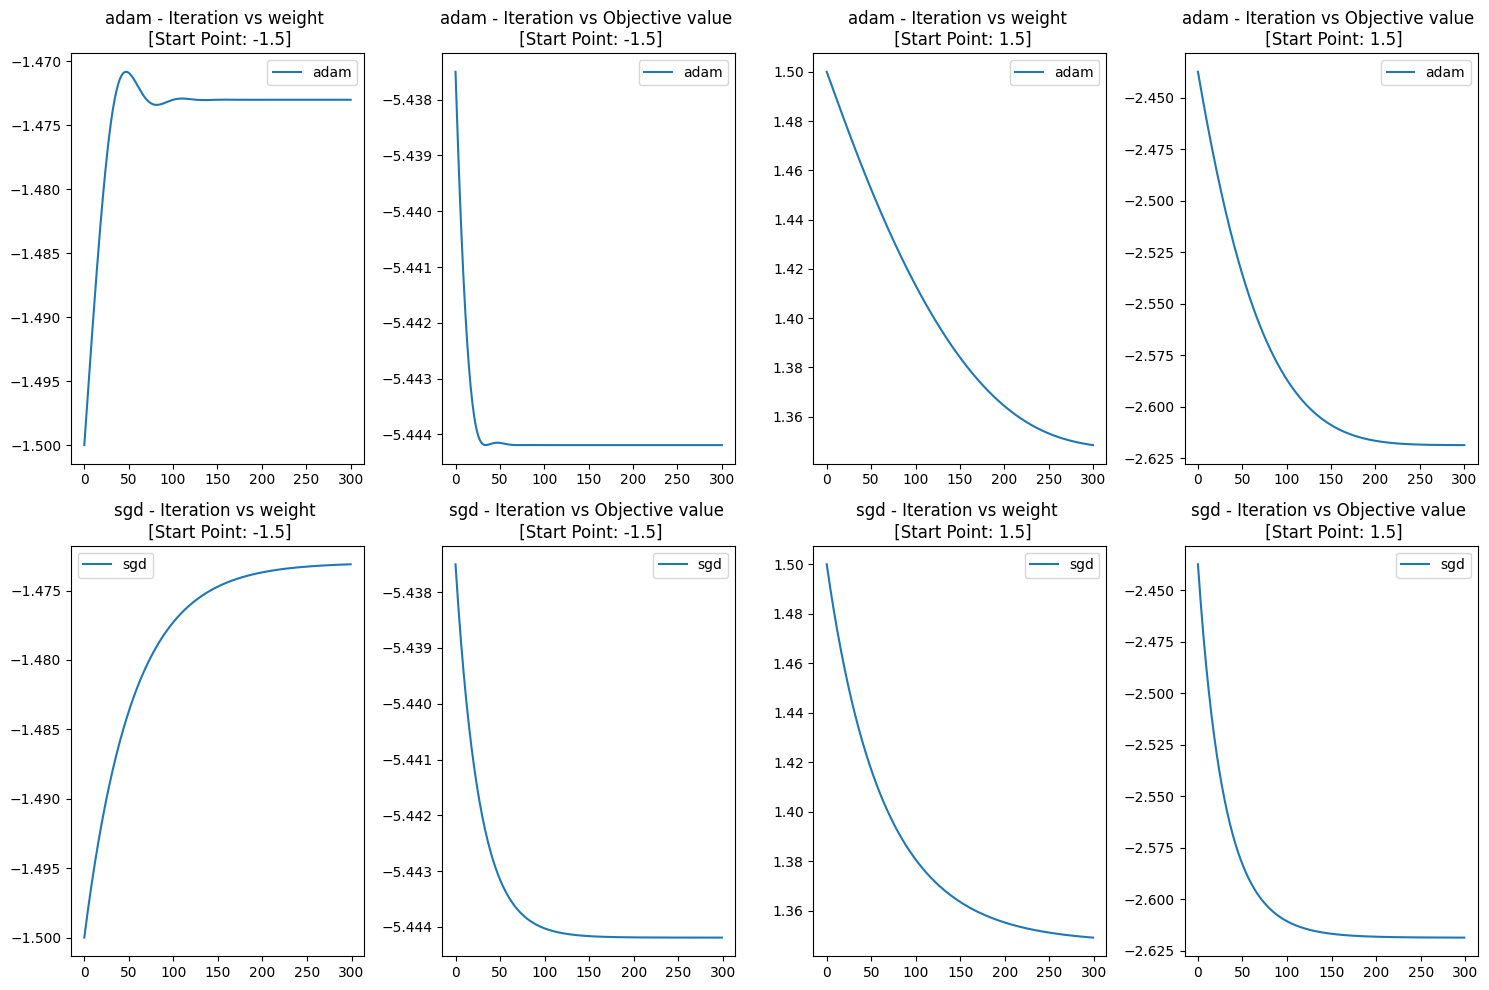

In [40]:
schemes = ['adam', 'sgd']
starts = [-1.5, 1.5]
data = { 
    "adam": [adam_hist_N1pt5, adam_hist_1pt5],
    "sgd" : [sgd_hist_N1pt5, sgd_hist_1pt5]
}
fig, axes = plt.subplots(len(schemes), 4, figsize=(15, 10))

for idx, (scheme, start) in enumerate(zip(schemes, starts)):
    axes[idx, 0].plot(range(0, len(data[scheme][0][:,0])), data[scheme][0][:,0], label=scheme)
    axes[idx, 0].set_title(f"{scheme} - Iteration vs weight \n [Start Point: -1.5]")
    axes[idx, 0].legend()
    axes[idx, 1].plot(range(0, len(data[scheme][0][:,1])), data[scheme][0][:,1], label=scheme)
    axes[idx, 1].set_title(f"{scheme} - Iteration vs Objective value \n [Start Point: -1.5]")
    axes[idx, 1].legend()

    axes[idx, 2].plot(range(0, len(data[scheme][1][:,0])), data[scheme][1][:,0], label=scheme)
    axes[idx, 2].set_title(f"{scheme} - Iteration vs weight \n [Start Point: 1.5]")
    axes[idx, 2].legend()
    axes[idx, 3].plot(range(0, len(data[scheme][1][:,1])), data[scheme][1][:,1], label=scheme)
    axes[idx, 3].set_title(f"{scheme} - Iteration vs Objective value \n [Start Point: 1.5]")
    axes[idx, 3].legend()

plt.tight_layout()
plt.show()

 Report the final converged values. Briefly explain:        
• Why different initializations converge to different minima.       
• Why fixing random seeds is important for reproducibility.     
• Whytrying multiple seeds can help discover better minima in non-convex problems       

• Why different initializations converge to different minima.   

Both Adam and SGD converge to the same final values (–1.475 for weight, –5.444 for objective), regardless of whether they start at –1.5 or +1.5.

The difference lies in the trajectory: Adam adjusts sharply and stabilizes quickly, while SGD moves more gradually.

• Why fixing random seeds is important for reproducibility

In more complex, non‑convex problems, different initializations could lead to genuinely different minima, which is why seeds matter both for reproducibility and for exploring better solutions.

• Why trying multiple seeds can help discover better minima in non-convex problems

Fixing a seed gives reproducibility, but it might lock you into a suboptimal minimum.
Running with multiple seeds explores different regions of the loss surface.
This increases the chance of finding a better minimum (lower loss, better generalization).
In practice, researchers often average across seeds or select the best run.

---
**Problem 14**

Consider minimizing the function:       
f(w1,w2) = 1/2 (10w1^2 + w2^2)      

In [3]:
import numpy as np

def func14(w1, w2):
    return 0.5 * (10*w1**2 + w2**2)

def df_func14(w1, w2):
    return np.array([10*w1, w2])

(a) Implement from scratch:          
• Vanilla Gradient Descent          
• Gradient Descent with Momentum            

SGD : Use the update rule: 

w <sub>{t+1}</sub> = w<sub>t</sub> −η *gt

In [39]:
def sgd_14(epochs=500, lr=0.001, start=(1.0, 2.0)):
    (w1, w2) = start
    history = []

    history.append((w1, w2, func14(w1, w2)))

    for idx, epoch in enumerate(range(1, epochs+1)):
        gt = df_func14(w1, w2)

        w1 -= lr*gt[0]
        w2 -= lr*gt[1]
        history.append((w1, w2, func14(w1, w2)))
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: w1={w1:.4f}, w2={w2:.4f}, f(x,y)={func14(w1, w2):.6f}")       
    
    return np.array(history)       

Momentum: Use the update rules: 

v<sub>t</sub> = βv<sub>t−1</sub> +gt    
w<sub>t+1</sub> = w<sub>t</sub> −ηv<sub>t</sub>     

In [40]:
def momentum_14(epochs=500, lr=0.001, beta=0.99, start=(1.0, 2.0)):
    (w1, w2) = start

    # Size of vt depends on input size
    # Currently two
    vt = np.zeros(2)

    history = []

    history.append((w1, w2, func14(w1, w2)))

    for idx, epoch in enumerate(range(1, epochs+1)):
        gt = df_func14(w1, w2)

        vt[0] = beta * vt[0] + gt[0]
        vt[1] = beta * vt[1] + gt[1]

        w1 -= lr * vt[0]
        w2 -= lr * vt[1]

        history.append((w1, w2, func14(w1, w2)))
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: w1={w1:.4f}, w2={w2:.4f}, f(x,y)={func14(w1, w2):.6f}")       
    
    return np.array(history)        


In [41]:
sgd_hist_14 = sgd_14(epochs=100, lr=0.1, start=(2.0, 2.0))

Epoch 50: w1=0.0000, w2=0.0103, f(x,y)=0.000053
Epoch 100: w1=0.0000, w2=0.0001, f(x,y)=0.000000


In [42]:
momentun_hist_14 = momentum_14(epochs=100, lr=0.1, beta=0.9, start=(2.0, 2.0))

Epoch 50: w1=-0.0993, w2=-0.1334, f(x,y)=0.058200
Epoch 100: w1=0.0027, w2=0.0075, f(x,y)=0.000064


 Report:    
• Final parameter values    
• Final loss    

In [43]:
vgd_final = sgd_hist_14[-1]
print("Vanilla GD")
print(f"Parameters: w1={vgd_final[0]:.4f}, w2:{vgd_final[1]:.4f}")
print(f"Final Loss: {vgd_final[2]:.4f}")

mom_final = momentun_hist_14[-1]
print("\nMomentum")
print(f"Parameters: w1={mom_final[0]:.4f}, w2:{mom_final[1]:.4f}")
print(f"Final Loss: {mom_final[2]:.4f}")


Vanilla GD
Parameters: w1=0.0000, w2:0.0001
Final Loss: 0.0000

Momentum
Parameters: w1=0.0027, w2:0.0075
Final Loss: 0.0001


<details>
<summary>Another approach to the same problem to acertain as the results are counterinutive from last run where Vanila GD converges faster than Momentum</summary>

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# The objective function: f(w1, w2) = 0.5 * (10w1^2 + w2^2)
def f(w1, w2):
    return 0.5 * (10 * w1**2 + w2**2)

# Gradient: df/dw1 = 10w1, df/dw2 = w2
def gradient(w):
    return np.array([10 * w[0], w[1]])

def run_gd(w_start, eta, steps):
    w = np.array(w_start, dtype=float)
    history = [w.copy()]
    print("GD Run")
    print(f"{w} , F={f(w[0], w[1])}")
    for step in range(steps):
        gt = gradient(w)
        w = w - eta * gt
        history.append(w.copy())
        if step % 50==0:
            print(f"{w} , F={f(w[0], w[1])}")
    return np.array(history)

def run_momentum(w_start, eta, beta, steps):
    w = np.array(w_start, dtype=float)
    v = np.zeros_like(w)
    history = [w.copy()]
    print("Momentum Run")
    print(f"{w} , F={f(w[0], w[1])}")
    for step in range(steps):
        gt = gradient(w)
        v = beta * v + gt
        w = w - eta * v
        history.append(w.copy())
        if step % 50==0:
            print(f"{w} , F={f(w[0], w[1])}")
    return np.array(history)

# Configuration to match your results
w_initial = [2.0, 2.0]
learning_rate = 0.1
beta = 0.999
steps = 100

# Generate histories
history_gd = run_gd(w_initial, learning_rate, steps)
history_mom = run_momentum(w_initial, learning_rate, beta, steps)

GD Run
[2. 2.] , F=22.0
[0.  1.8] , F=1.62
[0.        0.0092768] , F=4.302946619789168e-05
Momentum Run
[2. 2.] , F=22.0
[0.  1.8] , F=1.62
[-1.93284564 -1.57271444] , F=19.91617673477511


• Plot loss vs iterations (log scale)       
• Plot trajectory in (w1,w2) space      

</details>

In [47]:
# Setup Plotting Area
w1_range = np.linspace(-2.5, 2.5, 400)
w2_range = np.linspace(-2.5, 2.5, 400)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = func14(W1, W2)

In [69]:
#print(history_gd[:,1])
#print(sgd_hist_14[:,1])

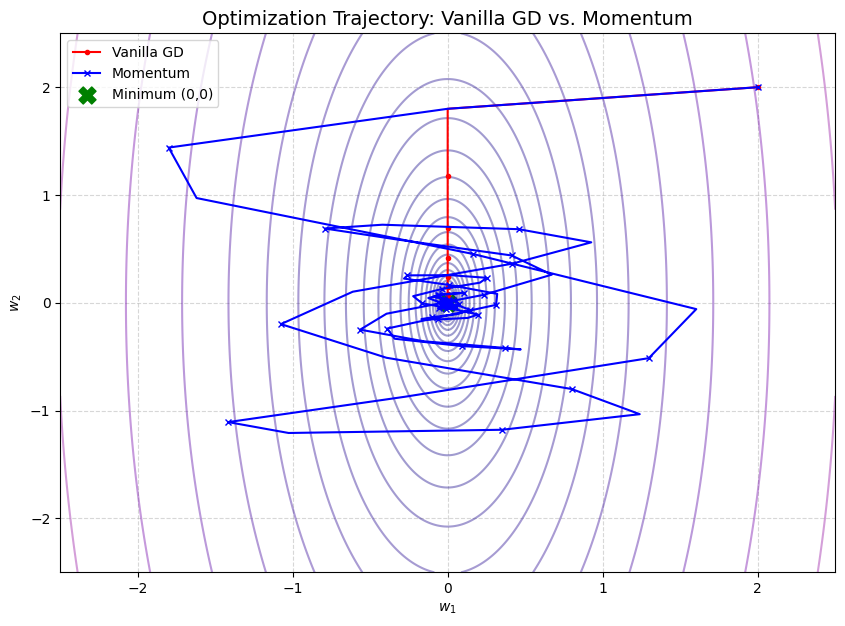

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
# Plot contours on a log scale to better visualize the "valley"
plt.contour(W1, W2, Z, levels=np.logspace(-2, 2, 25), cmap='plasma', alpha=0.4)

# Plot trajectories
plt.plot(sgd_hist_14[:, 0], sgd_hist_14[:, 1], 'o-', color='red', 
         markersize=3, label='Vanilla GD', markevery=5)
plt.plot(momentun_hist_14[:, 0], momentun_hist_14[:, 1], 'x-', color='blue', 
         markersize=4, label='Momentum', markevery=2)

plt.scatter(0, 0, color='green', marker='X', s=150, label='Minimum (0,0)')

plt.title('Optimization Trajectory: Vanilla GD vs. Momentum', fontsize=14)
plt.xlabel('$w_1$')
plt.ylabel('$w_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

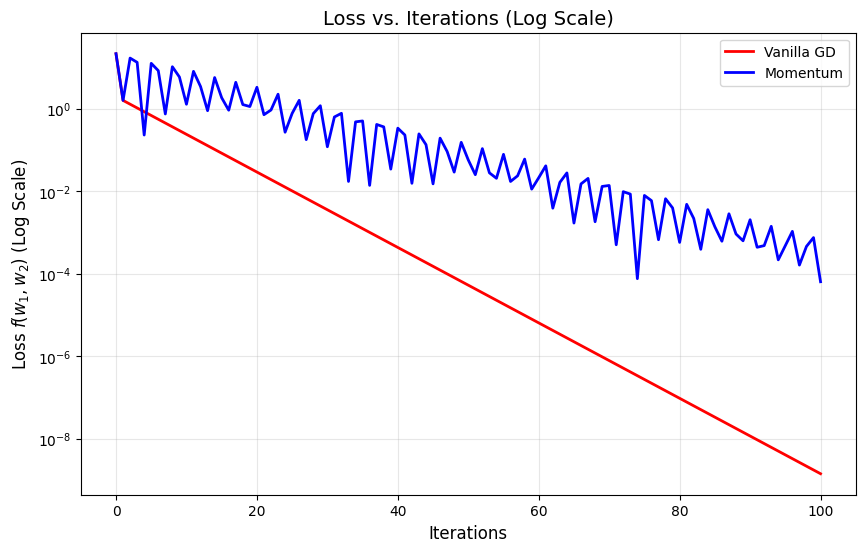

In [68]:
# Visualization
plt.figure(figsize=(10, 6))
plt.plot(range(len(sgd_hist_14[:,2])), sgd_hist_14[:,2], label='Vanilla GD', color='red', lw=2)
plt.plot(range(len(momentun_hist_14[:,2])), momentun_hist_14[:,2], label='Momentum', color='blue', lw=2)

plt.yscale('log')  # Logarithmic scale for y-axis
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss $f(w_1, w_2)$ (Log Scale)', fontsize=12)
plt.title('Loss vs. Iterations (Log Scale)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

(d) Explain why Momentum converges faster along the shallow curvature direction compared
to vanilla SGD. Relate your explanation to the eigenvalues of the Hessian

To understand why Momentum outperforms vanilla SGD in shallow regions, we have to look at the "topography" of the function through the lens of the Hessian matrix ($H$).

For function $f(w_1, w_2) = \frac{1}{2}(10w_1^2 + w_2^2)$, 

Hessian is:$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial w_1^2} & \frac{\partial^2 f}{\partial w_1 \partial w_2} \\ \frac{\partial^2 f}{\partial w_2 \partial w_1} & \frac{\partial^2 f}{\partial w_2^2} \end{bmatrix} = \begin{bmatrix} 10 & 0 \\ 0 & 1 \end{bmatrix}$$


1. Eigenvalues and CurvatureThe eigenvalues of the Hessian ($\lambda_1 = 10, \lambda_2 = 1$) represent the curvature along the principal axes:

$\lambda_{max} = 10$: Steep curvature ($w_1$ axis).

$\lambda_{min} = 1$: Shallow curvature ($w_2$ axis).

In vanilla SGD, the learning rate $\eta$ is strictly limited by the largest eigenvalue. To prevent divergence in the steep direction, recommendation is to have $\eta < \frac{2}{\lambda_{max}}$. Because $\eta$ must be small to stay stable in the $w_1$ direction, the steps taken in the shallow $w_2$ direction (where the gradient is already small) become infinitesimally tiny.

2. The Momentum Advantage: Velocity Accumulation Momentum decouples the speed of convergence from the raw gradient magnitude through the velocity term $v_t = \beta v_{t-1} + g_t$.

In the Steep Direction ($\lambda_{max}$)The gradients $g_t$ tend to flip sign if the optimizer overshoots the narrow valley. When you add these oscillating gradients together in the $v_t$ term, they cancel each other out. This "dampening" allows Momentum to stay stable even with a slightly higher effective learning rate.In the Shallow Direction ($\lambda_{min}$). The gradients $g_t$ point in the same direction consistently (toward the optimum). Because they don't change sign, the velocity $v_t$ builds up over time.In SGD, the step is $\eta g_t$. In Momentum, after many steps, the velocity reaches a "terminal velocity" of approximately $\frac{1}{1-\beta} g_t$. If $\beta = 0.9$, the effective step size in the shallow direction becomes 10 times larger than vanilla SGD.

---

**Problem 15**

Gradient Descent vs Newton’s Method     

Consider the function
f(w1,w2) = 3w1^2 +2w1w2 +2w2^2

The loss value at iteration t is defined as

Lt = f(w(t)1 , w(t)2)

where w(t)1 and w(t)2 denote the parameter values at iteration t.

In [74]:
import numpy as np

def func_15(w):
    return 3*w[0]**2 + 2*w[0]*w[1] + 2*w[1]**2

def df_func15(w):
    return np.array([6*w[0] + 2*w[1], 2*w[0] + 4*w[1]])

def hessian_15(w):
    # The Hessian of this function is constant and positive definite, 
    # therefore the function is convexand has a unique global minimum
    return np.array([[6, 0],[0, 4]]) 

 Implement the following optimization algorithms. Use PyTorch, TensorFlow, or built-in
optimizer libraries.        
• Gradient Descent      
• Newton’s Method       

In [139]:
def sgd_15(epochs=500, lr=0.01, start=[1.0, 1.0]):
    history = []
    start = np.array(start)
    history.append((start[0], start[1], func_15(start)))
    print("SGD: ")
    print(f"Epoch {0}: {start}: {func_15(start)}")
    for epoch in range(1, epochs+1):
        gt = df_func15(start)
        start -= lr*gt
        history.append((start[0], start[1], func_15(start)))
        if epoch % 50==0:
            print(f"Epoch {epoch}: {start}: {func_15(start)}")

    return np.array(history)

In [145]:
def newton_15(epochs=500, start=[1.0, 1.0]):
    history = []
    start = np.array(start)
    history.append((start[0], start[1], func_15(start)))
    print("Newton: ")
    print(f"Epoch {0}: {start}: {func_15(start)}")
    for epoch in range(1, epochs+1):
        gt = df_func15(start)
        gtt = hessian_15(start)
        start -= np.linalg.inv(gtt).dot(gt)
        history.append((start[0], start[1], func_15(start)))
        if epoch % 5==0:
            print(f"Epoch {epoch}: {start}: {func_15(start)}")

    return np.array(history)

In [140]:
sgd_hist_15 = sgd_15(epochs=50, lr=0.1, start=[4.0, 4.0])

SGD: 
Epoch 0: [4. 4.]: 112.0
Epoch 50: [-6.45255348e-08  1.04404508e-07]: 2.081772320725474e-14


In [141]:
sgd_hist_15

array([[ 4.00000000e+00,  4.00000000e+00,  1.12000000e+02],
       [ 8.00000000e-01,  1.60000000e+00,  9.60000000e+00],
       [ 0.00000000e+00,  8.00000000e-01,  1.28000000e+00],
       [-1.60000000e-01,  4.80000000e-01,  3.84000000e-01],
       [-1.60000000e-01,  3.20000000e-01,  1.79200000e-01],
       [-1.28000000e-01,  2.24000000e-01,  9.21600000e-02],
       [-9.60000000e-02,  1.60000000e-01,  4.81280000e-02],
       [-7.04000000e-02,  1.15200000e-01,  2.51904000e-02],
       [-5.12000000e-02,  8.32000000e-02,  1.31891200e-02],
       [-3.71200000e-02,  6.01600000e-02,  6.90585600e-03],
       [-2.68800000e-02,  4.35200000e-02,  3.61594880e-03],
       [-1.94560000e-02,  3.14880000e-02,  1.89333504e-03],
       [-1.40800000e-02,  2.27840000e-02,  9.91363072e-04],
       [-1.01888000e-02,  1.64864000e-02,  5.19084442e-04],
       [-7.37280000e-03,  1.19296000e-02,  2.71796142e-04],
       [-5.33504000e-03,  8.63232000e-03,  1.42314308e-04],
       [-3.86048000e-03,  6.24640000e-03

In [146]:
newton_hist_15 = newton_15(epochs=5, start=[4.0, 4.0])

Newton: 
Epoch 0: [4. 4.]: 112.0
Epoch 5: [-0.03703704 -0.05555556]: 0.014403292181069938


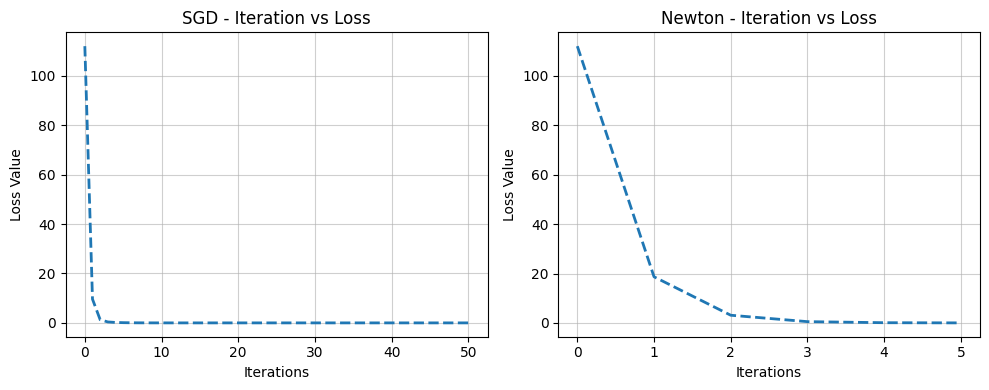

In [164]:
import matplotlib.pyplot as plt

_, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].plot(range(0, len(sgd_hist_15)), sgd_hist_15[:, 2], linewidth=2, linestyle="--")
axes[0].set_title("SGD - Iteration vs Loss")
axes[0].set_xlabel("Iterations")
axes[0].set_ylabel("Loss Value")
axes[1].plot(range(0, len(newton_hist_15)), newton_hist_15[:, 2], linewidth=2, linestyle="--")
axes[1].set_title("Newton - Iteration vs Loss")
axes[1].set_xlabel("Iterations")
axes[1].set_ylabel("Loss Value")

axes[0].grid(True, alpha=0.6)
axes[1].grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

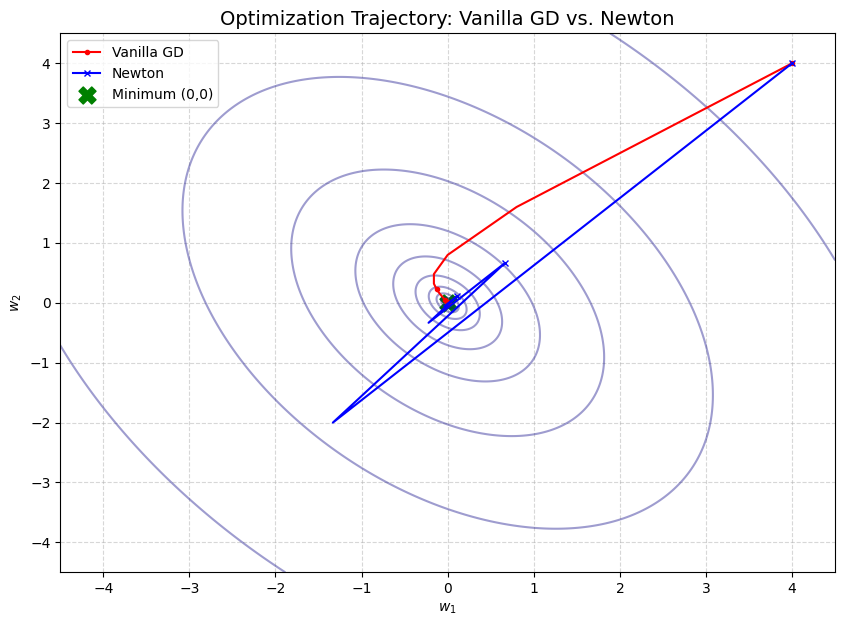

In [163]:
w1_range = np.linspace(-4.5, 4.5, 400)
w2_range = np.linspace(-4.5, 4.5, 400)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = func_15([W1, W2])

plt.figure(figsize=(10, 7))
# Plot contours on a log scale to better visualize the "valley"
plt.contour(W1, W2, Z, levels=np.logspace(-5.5, 5.5, 25), cmap='plasma', alpha=0.4)

# Plot trajectories
plt.plot(sgd_hist_15[:, 0], sgd_hist_15[:, 1], 'o-', color='red', 
         markersize=3, label='Vanilla GD', markevery=5)
plt.plot(newton_hist_15[:, 0], newton_hist_15[:, 1], 'x-', color='blue', 
         markersize=4, label='Newton', markevery=2)

plt.scatter(0, 0, color='green', marker='X', s=150, label='Minimum (0,0)')

plt.title('Optimization Trajectory: Vanilla GD vs. Newton', fontsize=14)
plt.xlabel('$w_1$')
plt.ylabel('$w_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Briefly compare the convergence behavior of the two methods

Newton’s method converges much faster near the optimum (quadratic convergence) but is computationally expensive, while stochastic gradient descent (SGD) converges more slowly (sublinear rates) yet scales well to large datasets and high dimensions. In practice, SGD is favored for large-scale machine learning, while Newton’s method is used when precision and curvature information justify the cost.